# ThermaWatch - Dual-Branch Neuro-Fuzzy LSTM (ANFIS-LSTM)

## Cell 1 - Mount Google Drive

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import os

DATASET_PATH = '/content/drive/MyDrive/Kuliah/Dataset_(Jan,2014-Mei,2026).csv'

if os.path.exists(DATASET_PATH):
    size_mb = os.path.getsize(DATASET_PATH) / 1_000_000
    print(f"Dataset ditemukan: {DATASET_PATH}")
    print(f"Ukuran file: {size_mb:.1f} MB")
else:
    print("Dataset TIDAK ditemukan di path tersebut.")
    print("Pastikan file ada di: MyDrive/Kuliah/Dataset_(Jan,2014-Mei,2026).csv")
    print("Atau ubah DATASET_PATH di atas sesuai lokasi file Anda.")

Mounted at /content/drive
Dataset ditemukan: /content/drive/MyDrive/Kuliah/Dataset_(Jan,2014-Mei,2026).csv
Ukuran file: 30.3 MB


## Cell 2 - Install Dependencies & Cek GPU

In [2]:
# Install dependencies (torch sudah tersedia di Colab)
# Hanya scikit-learn & matplotlib yang perlu dipastikan
!pip install -q scikit-learn matplotlib pandas torch

import torch
print(f"PyTorch version : {torch.__version__}")
print(f"CUDA available  : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU             : {torch.cuda.get_device_name(0)}")
    print(f"VRAM            : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
else:
    print("Tidak ada GPU - training akan lebih lambat di CPU.")
    print("Aktifkan GPU: Runtime -> Change runtime type -> T4 GPU")

PyTorch version : 2.11.0+cu128
CUDA available  : True
GPU             : Tesla T4
VRAM            : 15.6 GB


## Cell 3 - Import Library & Konfigurasi Global

In [3]:
# BAGIAN 0 - IMPORT & KONFIGURASI GLOBAL

import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR

from sklearn.preprocessing import StandardScaler

import pickle

warnings.filterwarnings("ignore")

# Reproducibility seed
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

# Hyperparameter utama
class CFG:
    # Path dataset (sudah diisi otomatis dari Cell 1)
    DATA_PATH = '/content/drive/MyDrive/Kuliah/Dataset_(Jan,2014-Mei,2026).csv'

    # Output directory (model & plot disimpan ke Drive)
    OUTPUT_DIR = '/content/drive/MyDrive/Kuliah/outputs/'

    # Window & split
    LOOKBACK    = 14          # jumlah hari historis per window
    TRAIN_RATIO = 0.70        # 70% train
    VAL_RATIO   = 0.15        # 15% val -> sisa 15% test

    # Kolom fitur
    DYNAMIC_COLS = ['MODIS_LST_Mean', 'LST_Mean', 'LST_Anomaly']          # Branch A
    STATIC_COLS  = ['Elevation_m', 'NDVI_8Day_Mean', 'SoilMoisture_Daily_Mean']  # Branch B
    TARGET_COLS  = ['Target_Anomali_H1', 'Target_Anomali_H3', 'Target_Anomali_H7']

    # Dimensi model
    FUZZY_SETS   = 5           # jumlah himpunan fuzzy per fitur
    LSTM_HIDDEN  = 256         # ukuran hidden state LSTM
    LSTM_LAYERS  = 2           # jumlah stacked LSTM layer
    LSTM_DROPOUT = 0.30        # dropout antar layer LSTM
    ENV_EMBED    = 64          # ukuran embedding Branch B
    MLP_HIDDEN   = 128          # lebar shared MLP setelah fusion

    # Training
    BATCH_SIZE   = 256
    EPOCHS       = 60
    LR           = 1e-4
    WEIGHT_DECAY = 1e-3
    HUBER_DELTA  = 1.0         # delta untuk Smooth L1 / Huber Loss
    T_MAX        = 60          # periode cosine annealing = total epoch

    DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

# Buat output directory jika belum ada
os.makedirs(CFG.OUTPUT_DIR, exist_ok=True)

print(f"Konfigurasi dimuat.")
print(f"Device     : {CFG.DEVICE}")
print(f"Output dir : {CFG.OUTPUT_DIR}")
print(f"Data path  : {CFG.DATA_PATH}")

Konfigurasi dimuat.
Device     : cuda
Output dir : /content/drive/MyDrive/Kuliah/outputs/
Data path  : /content/drive/MyDrive/Kuliah/Dataset_(Jan,2014-Mei,2026).csv


## Cell 4 - Custom Dataset & DataLoader

In [4]:
# BAGIAN 1 - DATA LOADER & PREPROCESSING (UPDATED RANDOM SPLIT)
from torch.utils.data import random_split

class ThermaWatchDataset(Dataset):
    """
    Custom PyTorch Dataset untuk data deret waktu multi-lokasi.
    Menerima pre-built arrays untuk menghindari data leakage saat pengacakan.
    """
    def __init__(self, windows_dyn, windows_stat, windows_y):
        super().__init__()
        # Langsung konversi array numpy ke tensor PyTorch
        self.X_dyn  = torch.tensor(windows_dyn,  dtype=torch.float32)
        self.X_stat = torch.tensor(windows_stat, dtype=torch.float32)
        self.Y      = torch.tensor(windows_y,    dtype=torch.float32)

    def __len__(self):
        return len(self.X_dyn)

    def __getitem__(self, idx):
        return self.X_dyn[idx], self.X_stat[idx], self.Y[idx]


def build_dataloaders(data_path=CFG.DATA_PATH):
    print('=' * 65)
    print('  [1/4] Membaca dataset ...')
    df = pd.read_csv(data_path, parse_dates=['date'])
    df = df.sort_values(['Kabupaten', 'date']).reset_index(drop=True)
    print(f'        Total baris  : {len(df):,}')
    print(f'        Jumlah Kab   : {df["Kabupaten"].nunique()}')
    print(f'        Rentang waktu: {df["date"].min().date()} -> {df["date"].max().date()}')

    # 1. Tentukan porsi data untuk fitting scaler
    train_size_fit = int(len(df) * 0.8)
    df_fit_scaler = df.iloc[:train_size_fit]

    scaler_dyn  = StandardScaler()
    scaler_stat = StandardScaler()
    scaler_y    = StandardScaler()

    # Fit scaler
    scaler_dyn.fit(df_fit_scaler[CFG.DYNAMIC_COLS].values)
    scaler_stat.fit(df_fit_scaler[CFG.STATIC_COLS].values)
    scaler_y.fit(df_fit_scaler[CFG.TARGET_COLS].values)

    # LANGSUNG AMANKAN & SIMPAN KETIGA SCALER VALID KE DRIVE SAAT INI JUGA
    scaler_path = CFG.OUTPUT_DIR + 'scalers_modis.pkl'
    with open(scaler_path, 'wb') as f:
        pickle.dump({
            'scaler_dyn': scaler_dyn,
            'scaler_stat': scaler_stat,
            'scaler_y': scaler_y
        }, f)
    print(f"        File Scaler Resmi berhasil diamankan ke: {scaler_path}")

    # Transform seluruh dataset master
    dyn_scaled  = scaler_dyn.transform(df[CFG.DYNAMIC_COLS].values).astype(np.float32)
    stat_scaled = scaler_stat.transform(df[CFG.STATIC_COLS].values).astype(np.float32)
    y_scaled    = scaler_y.transform(df[CFG.TARGET_COLS].values).astype(np.float32)

    # 2. Bangun seluruh objek sliding window secara utuh (Per Kabupaten)
    print('\n  [2/4] Membangun seluruh window spasial-temporal ...')
    all_windows_dyn, all_windows_stat, all_windows_y = [], [], []

    for kab, grp in df.groupby('Kabupaten', sort=False):
        idx = grp.index.tolist()
        n   = len(idx)
        for i in range(CFG.LOOKBACK, n):
            win_idx = idx[i - CFG.LOOKBACK : i]
            tgt_idx = idx[i]
            all_windows_dyn.append(dyn_scaled[win_idx])
            all_windows_stat.append(stat_scaled[win_idx[-1]])
            all_windows_y.append(y_scaled[tgt_idx])

    all_windows_dyn  = np.array(all_windows_dyn)
    all_windows_stat = np.array(all_windows_stat)
    all_windows_y    = np.array(all_windows_y)

    full_dataset = ThermaWatchDataset(all_windows_dyn, all_windows_stat, all_windows_y)
    total_windows = len(full_dataset)
    print(f'        Total Windows Terbentuk: {total_windows:,}')

    n_train = int(total_windows * CFG.TRAIN_RATIO)
    n_val   = int(total_windows * CFG.VAL_RATIO)
    n_test  = total_windows - n_train - n_val

    generator = torch.Generator().manual_seed(SEED)
    ds_train, ds_val, ds_test = random_split(
        full_dataset, [n_train, n_val, n_test], generator=generator
    )

    print(f'\n  [3/4] Random Split Objek Window Selesai:')
    print(f'        Train Windows : {len(ds_train):,}')
    print(f'        Val Windows   : {len(ds_val):,}')
    print(f'        Test Windows  : {len(ds_test):,}')

    dl_train = DataLoader(ds_train, batch_size=CFG.BATCH_SIZE, shuffle=True,
                          num_workers=2, pin_memory=(CFG.DEVICE == 'cuda'))
    dl_val   = DataLoader(ds_val,   batch_size=CFG.BATCH_SIZE, shuffle=False, num_workers=2)
    dl_test  = DataLoader(ds_test,  batch_size=CFG.BATCH_SIZE, shuffle=False, num_workers=2)

    print(f'\n  [4/4] DataLoader siap. Batch size={CFG.BATCH_SIZE}.')
    print('=' * 65)
    return dl_train, dl_val, dl_test, scaler_y

# Eksekusi ulang pembentukan dataloader baru
dl_train, dl_val, dl_test, scaler_y = build_dataloaders()

  [1/4] Membaca dataset ...
        Total baris  : 85,994
        Jumlah Kab   : 19
        Rentang waktu: 2014-01-01 -> 2026-05-23
        File Scaler Resmi berhasil diamankan ke: /content/drive/MyDrive/Kuliah/outputs/scalers_modis.pkl

  [2/4] Membangun seluruh window spasial-temporal ...
        Total Windows Terbentuk: 85,728

  [3/4] Random Split Objek Window Selesai:
        Train Windows : 60,009
        Val Windows   : 12,859
        Test Windows  : 12,860

  [4/4] DataLoader siap. Batch size=256.


## Cell 5 - Arsitektur Model ANFIS-LSTM

### Fuzzy Layer
Gaussian MF formula: μ(x) = exp(−(x − c)² / (2σ²)).
`centers` and `log_sigma` are `nn.Parameter` for backprop optimization. All operations use PyTorch broadcasting.

### Late Fusion + LayerNorm
`LayerNorm` is applied after concatenation to prevent `Elevation_m` from dominating LSTM gradients without normalization.

In [5]:
# ============================================================
#  BAGIAN 2 — ARSITEKTUR MODEL
# ============================================================

# ── 2A. Differentiable Fuzzy Layer (Gaussian MF) ─────────────────────────────
class DifferentiableFuzzyLayer(nn.Module):
    """
    Fuzzifikasi differentiable menggunakan Gaussian Membership Functions.

    Input  : [batch, seq_len, n_features]
    Output : [batch, seq_len, n_features * n_fuzzy_sets]

    Tidak ada loop Python — semua via broadcasting PyTorch.
    """

    def __init__(self, n_features, n_fuzzy_sets):
        super().__init__()
        self.n_features   = n_features
        self.n_fuzzy_sets = n_fuzzy_sets

        # Inisialisasi pusat fuzzy merata di [-2, 2] (data ~N(0,1) setelah scaler)
        init_centers = torch.linspace(-2, 2, n_fuzzy_sets)
        init_centers = init_centers.unsqueeze(0).repeat(n_features, 1)  # [F, S]

        # σ = 0.8 → overlap ~50% antar MF bertetangga
        init_sigma = torch.ones(n_features, n_fuzzy_sets) * 0.8

        # nn.Parameter → dioptimasi bersama bobot model
        self.centers   = nn.Parameter(init_centers)
        self.log_sigma = nn.Parameter(torch.log(init_sigma))  # simpan log σ agar σ > 0

    def forward(self, x):
        # x: [B, T, F] → [B, T, F, 1]
        x_exp = x.unsqueeze(-1)

        # broadcast centers & sigma: [F, S] → [1, 1, F, S]
        c   = self.centers.unsqueeze(0).unsqueeze(0)
        sig = torch.exp(self.log_sigma).unsqueeze(0).unsqueeze(0)

        # Gaussian MF: μ = exp(-(x-c)^2 / (2σ^2))
        mu = torch.exp(-((x_exp - c) ** 2) / (2 * sig ** 2 + 1e-8))  # [B, T, F, S]

        B, T, F, S = mu.shape
        return mu.reshape(B, T, F * S)   # [B, T, F*S]


# ── 2B. Model Utama ANFIS_LSTM ────────────────────────────────────────────────
class ANFIS_LSTM(nn.Module):
    """
    Dual-Branch Neuro-Fuzzy LSTM.

    Branch A : DifferentiableFuzzyLayer → LSTM → h_n  [B, 128]
    Branch B : Dense bypass → env_emb               [B,  32]
    Fusion   : Concat → LayerNorm → Shared MLP      [B,  64]
    Output   : Head_H1, Head_H3, Head_H7            [B,   3]
    """

    def __init__(self,
                 n_dynamic    = len(CFG.DYNAMIC_COLS),
                 n_static     = len(CFG.STATIC_COLS),
                 n_fuzzy      = CFG.FUZZY_SETS,
                 lstm_hidden  = CFG.LSTM_HIDDEN,
                 lstm_layers  = CFG.LSTM_LAYERS,
                 lstm_drop    = CFG.LSTM_DROPOUT,
                 env_embed    = CFG.ENV_EMBED,
                 mlp_hidden   = CFG.MLP_HIDDEN):
        super().__init__()

        # ── BRANCH A ─────────────────────────────────────────────────────────
        fuzzy_out = n_dynamic * n_fuzzy   # 3 × 5 = 15

        self.fuzzy_layer = DifferentiableFuzzyLayer(n_dynamic, n_fuzzy)

        self.lstm = nn.LSTM(
            input_size  = fuzzy_out,
            hidden_size = lstm_hidden,
            num_layers  = lstm_layers,
            batch_first = True,
            dropout     = lstm_drop if lstm_layers > 1 else 0.0,
        )

        # ── BRANCH B ─────────────────────────────────────────────────────────
        self.env_branch = nn.Sequential(
            nn.Linear(n_static, env_embed),
            nn.ReLU(),
            nn.Linear(env_embed, env_embed),
            nn.ReLU(),
        )

        # ── LATE FUSION ───────────────────────────────────────────────────────
        fusion_dim = lstm_hidden + env_embed   # 128 + 32 = 160

        # LayerNorm KRITIS: mencegah Elevation mendominasi gradient LSTM
        self.fusion_norm = nn.LayerNorm(fusion_dim)

        # Shared MLP Base
        self.shared_mlp = nn.Sequential(
            nn.Linear(fusion_dim, mlp_hidden * 2),  # 160 → 128
            nn.GELU(),
            nn.Dropout(0.25),
            nn.Linear(mlp_hidden * 2, mlp_hidden),  # 128 → 64
            nn.GELU(),
            nn.Dropout(0.15),
        )

        # ── MULTI-HEAD OUTPUT ─────────────────────────────────────────────────
        self.head_h1 = nn.Linear(mlp_hidden, 1)   # H+1 day
        self.head_h3 = nn.Linear(mlp_hidden, 1)   # H+3 days
        self.head_h7 = nn.Linear(mlp_hidden, 1)   # H+7 days

        self._init_weights()

    def _init_weights(self):
        """Orthogonal init untuk LSTM, Xavier untuk Dense layers."""
        for name, p in self.named_parameters():
            if 'lstm' in name:
                if 'weight_ih' in name or 'weight_hh' in name:
                    nn.init.orthogonal_(p)
                elif 'bias' in name:
                    nn.init.zeros_(p)
            elif 'weight' in name and p.dim() >= 2:
                nn.init.xavier_uniform_(p)
            elif 'bias' in name:
                nn.init.zeros_(p)

    def forward(self, x_dyn, x_stat):
        """
        x_dyn  : [B, 14, 3]  — fitur dinamis Branch A
        x_stat : [B, 3]      — fitur statis Branch B
        return : [B, 3]      — prediksi [H1, H3, H7]
        """
        # ① Fuzzifikasi timestep-wise
        fuzz = self.fuzzy_layer(x_dyn)         # [B, 14, 15]

        # ② LSTM → ambil final hidden state
        _, (h_n, _) = self.lstm(fuzz)          # h_n: [layers, B, 128]
        h_last = h_n[-1]                       # [B, 128]

        # ③ Env embedding
        env_emb = self.env_branch(x_stat)      # [B, 32]

        # ④ Concat + ⑤ LayerNorm
        fused = torch.cat([h_last, env_emb], dim=-1)   # [B, 160]
        fused = self.fusion_norm(fused)                # [B, 160] — normalized

        # ⑥ Shared MLP
        base = self.shared_mlp(fused)                  # [B, 64]

        # ⑦ Multi-head output
        return torch.cat([self.head_h1(base),
                          self.head_h3(base),
                          self.head_h7(base)], dim=-1)  # [B, 3]


# Instantiate model
model = ANFIS_LSTM().to(CFG.DEVICE)

# ── Ringkasan model ───────────────────────────────────────────────────────────
total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(model)
print(f"\nTotal parameters     : {total_params:,}")
print(f"Trainable parameters : {trainable_params:,}")

# ── Quick forward pass smoke test ────────────────────────────────────────────
x_dyn, x_stat, y = next(iter(dl_train))
with torch.no_grad():
    out = model(x_dyn.to(CFG.DEVICE), x_stat.to(CFG.DEVICE))
print(f"\n✅ Forward pass OK")
print(f"   Input  dyn : {tuple(x_dyn.shape)}")
print(f"   Input  stat: {tuple(x_stat.shape)}")
print(f"   Output     : {tuple(out.shape)}  ← [batch, 3] untuk H1, H3, H7")


ANFIS_LSTM(
  (fuzzy_layer): DifferentiableFuzzyLayer()
  (lstm): LSTM(15, 256, num_layers=2, batch_first=True, dropout=0.3)
  (env_branch): Sequential(
    (0): Linear(in_features=3, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=64, bias=True)
    (3): ReLU()
  )
  (fusion_norm): LayerNorm((320,), eps=1e-05, elementwise_affine=True)
  (shared_mlp): Sequential(
    (0): Linear(in_features=320, out_features=256, bias=True)
    (1): GELU(approximate='none')
    (2): Dropout(p=0.25, inplace=False)
    (3): Linear(in_features=256, out_features=128, bias=True)
    (4): GELU(approximate='none')
    (5): Dropout(p=0.15, inplace=False)
  )
  (head_h1): Linear(in_features=128, out_features=1, bias=True)
  (head_h3): Linear(in_features=128, out_features=1, bias=True)
  (head_h7): Linear(in_features=128, out_features=1, bias=True)
)

Total parameters     : 926,433
Trainable parameters : 926,433

✅ Forward pass OK
   Input  dyn : (256, 14, 3)
   Input  st

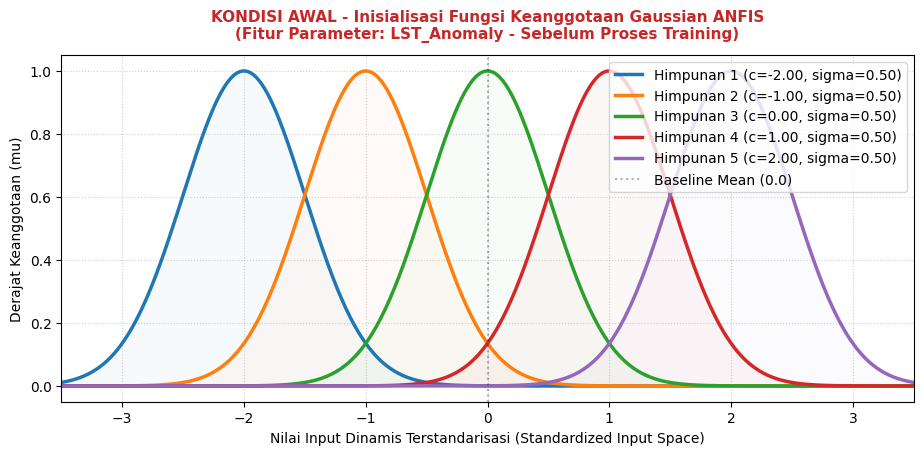

Grafik inisialisasi awal berhasil diamankan ke: /content/drive/MyDrive/Kuliah/outputs/anfis_membership_initial.png


In [6]:
# VISUALISASI ANFIS PART 1 - INISIALISASI AWAL GAUSSIAN MEMBERSHIP FUNCTION
import numpy as np
import matplotlib.pyplot as plt

def plot_initial_membership():
    """
    Fungsi untuk merekonstruksi dan menampilkan bentuk awal kurva keanggotaan fuzzy
    sebelum dilakukan pelatihan (Kondisi Ideal Uniform).
    """
    # Mengambil konfigurasi jumlah himpunan fuzzy dari CFG
    n_sets = CFG.FUZZY_SETS # 5 Himpunan Fuzzy

    # Rekonstruksi logika pembagian kuantil seragam seperti pada inisialisasi Cell 5
    init_centers = np.linspace(-2.0, 2.0, n_sets)
    init_sigmas = np.ones(n_sets) * (4.0 / (2 * (n_sets - 1)))

    # Rentang sumbu X untuk input data terstandarisasi
    x = np.linspace(-3.5, 3.5, 600)
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']

    plt.figure(figsize=(11, 4.5))

    # Menggambar kurva Gaussian untuk tiap himpunan
    for i in range(n_sets):
        # Rumus fisis Gaussian MF: mu(x) = exp(-0.5 * ((x - c) / sigma)^2)
        y_init = np.exp(-0.5 * ((x - init_centers[i]) / init_sigmas[i]) ** 2)

        plt.plot(x, y_init, color=colors[i], linewidth=2.5,
                 label=f'Himpunan {i+1} (c={init_centers[i]:.2f}, sigma={init_sigmas[i]:.2f})')
        plt.fill_between(x, 0, y_init, color=colors[i], alpha=0.03)

    plt.title('KONDISI AWAL - Inisialisasi Fungsi Keanggotaan Gaussian ANFIS\n(Fitur Parameter: LST_Anomaly - Sebelum Proses Training)',
              fontsize=11, fontweight='bold', color='#c62828', pad=12)
    plt.ylabel('Derajat Keanggotaan (mu)', fontsize=10)
    plt.xlabel('Nilai Input Dinamis Terstandarisasi (Standardized Input Space)', fontsize=10)
    plt.axvline(x=0, color='black', linestyle=':', alpha=0.3, label='Baseline Mean (0.0)')
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.legend(loc='upper right', frameon=True, shadow=False)
    plt.ylim(-0.05, 1.05)
    plt.xlim(-3.5, 3.5)

    # Auto-save ke direktori output Google Drive kamu untuk backup dokumen bab 4
    init_output_path = CFG.OUTPUT_DIR + 'anfis_membership_initial.png'
    plt.savefig(init_output_path, bbox_inches='tight', dpi=300)
    plt.show()
    print(f"Grafik inisialisasi awal berhasil diamankan ke: {init_output_path}")

# Jalankan fungsi visualisasi awal
plot_initial_membership()

## Cell 6 - Loss Function & Metrik Evaluasi

Huber Loss is chosen for its robustness to extreme thermal spikes:
- `|e| < δ`: behaves like L2 (smooth gradient)
- `|e| ≥ δ`: behaves like L1 (robust to outliers)

In [7]:
# BAGIAN 3 - LOSS, METRIK, TRAINING & EVALUASI FUNCTIONS
from sklearn.metrics import r2_score

def huber_loss(pred, target, delta=CFG.HUBER_DELTA):
    """Huber Loss (Smooth L1) - robust terhadap outlier spike termal."""
    return nn.functional.huber_loss(pred, target, delta=delta)


@torch.no_grad()
def compute_metrics(pred_np, target_np):
    """Hitung RMSE dan MAE untuk setiap cakrawala (H1, H3, H7)."""
    metrics = {}
    for i, lbl in enumerate(['H1', 'H3', 'H7']):
        diff = pred_np[:, i] - target_np[:, i]
        r2 = r2_score(target_np[:, i], pred_np[:, i])
        metrics[lbl] = {
            'RMSE': float(np.sqrt(np.mean(diff ** 2))),
            'MAE' : float(np.mean(np.abs(diff))),
            'R2'  : float(r2)
        }
    return metrics


def format_metrics(metrics, prefix=''):
    parts = [f"{h}: RMSE={v['RMSE']:.4f}°C  MAE={v['MAE']:.4f}°C R²={v['R2']:.4f}"
             for h, v in metrics.items()]
    return prefix + ' | '.join(parts)


def train_one_epoch(model, loader, optimizer, device):
    """Satu epoch training -> return rata-rata loss."""
    model.train()
    total_loss = 0.0
    for x_dyn, x_stat, y in loader:
        x_dyn, x_stat, y = x_dyn.to(device), x_stat.to(device), y.to(device)
        optimizer.zero_grad()
        pred = model(x_dyn, x_stat)
        loss = huber_loss(pred, y)
        loss.backward()
        # Gradient clipping mencegah exploding gradient di LSTM
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        total_loss += loss.item() * len(y)
    return total_loss / len(loader.dataset)


@torch.no_grad()
def evaluate(model, loader, scaler_y, device):
    """
    Evaluasi model.
    Inverse-transform prediksi & target ke satuan °C asli sebelum metrik dihitung.
    """
    model.eval()
    all_pred, all_target, total_loss = [], [], 0.0
    for x_dyn, x_stat, y in loader:
        x_dyn, x_stat, y = x_dyn.to(device), x_stat.to(device), y.to(device)
        pred = model(x_dyn, x_stat)
        total_loss += huber_loss(pred, y).item() * len(y)
        all_pred.append(pred.cpu().numpy())
        all_target.append(y.cpu().numpy())

    pred_np   = np.vstack(all_pred)
    target_np = np.vstack(all_target)

    # Kembalikan ke satuan °C asli
    pred_orig   = scaler_y.inverse_transform(pred_np)
    target_orig = scaler_y.inverse_transform(target_np)

    avg_loss = total_loss / len(loader.dataset)
    metrics  = compute_metrics(pred_orig, target_orig)
    return avg_loss, metrics, pred_orig, target_orig

print("Loss function & metrik siap.")

Loss function & metrik siap.


## Cell 7 - Training Loop

- AdamW: weight decay for implicit regularization.
- CosineAnnealingLR: smooth LR decay from `3e-4` to `1e-6` for convergence.
- The best model (lowest validation loss) is automatically saved to Google Drive.

In [19]:
# BAGIAN 3 (lanjutan) - MAIN TRAINING LOOP

def train(model, dl_train, dl_val, scaler_y,
          epochs=CFG.EPOCHS, device=CFG.DEVICE,
          save_path=CFG.OUTPUT_DIR + 'best_model_modis.pt'):

    print('\n' + '=' * 65)
    print(f'  MEMULAI TRAINING - Device: {device}')
    print(f'  Model params : {sum(p.numel() for p in model.parameters()):,}')
    print('=' * 65)

    optimizer = AdamW(model.parameters(), lr=CFG.LR, weight_decay=CFG.WEIGHT_DECAY)

    # Cosine Annealing: LR turun dari LR_max -> ~0 dalam T_MAX epoch
    scheduler = CosineAnnealingLR(optimizer, T_max=CFG.T_MAX, eta_min=1e-6)

    history = {
        'train_loss': [], 'val_loss': [],
        'val_H1_RMSE': [], 'val_H3_RMSE': [], 'val_H7_RMSE': [],
        'val_H1_MAE':  [], 'val_H3_MAE':  [], 'val_H7_MAE':  [],
    }
    best_val_loss = float('inf')

    for epoch in range(1, epochs + 1):
        train_loss = train_one_epoch(model, dl_train, optimizer, device)
        val_loss, val_metrics, _, _ = evaluate(model, dl_val, scaler_y, device)
        scheduler.step()

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        for h in ['H1', 'H3', 'H7']:
            history[f'val_{h}_RMSE'].append(val_metrics[h]['RMSE'])
            history[f'val_{h}_MAE'].append( val_metrics[h]['MAE'])

        lr_now = scheduler.get_last_lr()[0]
        print(f"  Epoch [{epoch:3d}/{epochs}] "
              f"Train={train_loss:.5f}  Val={val_loss:.5f}  LR={lr_now:.2e}")
        print(format_metrics(val_metrics, prefix='    -> '))

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save({
                'epoch'      : epoch,
                'model_state': model.state_dict(),
                'opt_state'  : optimizer.state_dict(),
                'val_loss'   : val_loss,
                'val_metrics': val_metrics,
            }, save_path)
            print(f'    Best model saved  (val_loss={val_loss:.5f}) -> {save_path}')

    print('=' * 65)
    print(f'  Training selesai. Best val loss: {best_val_loss:.5f}')
    print('=' * 65)
    return history


# Mulai training
history = train(model, dl_train, dl_val, scaler_y)


  MEMULAI TRAINING - Device: cuda
  Model params : 926,433
  Epoch [  1/60] Train=0.21493  Val=0.20515  LR=9.99e-05
    -> H1: RMSE=1.2889°C  MAE=0.8597°C R²=0.6059 | H3: RMSE=1.4828°C  MAE=1.0445°C R²=0.4892 | H7: RMSE=1.5992°C  MAE=1.1706°C R²=0.4134
    Best model saved  (val_loss=0.20515) -> /content/drive/MyDrive/Kuliah/outputs/best_model_modis.pt
  Epoch [  2/60] Train=0.20469  Val=0.19961  LR=9.97e-05
    -> H1: RMSE=1.2701°C  MAE=0.8285°C R²=0.6173 | H3: RMSE=1.4683°C  MAE=1.0185°C R²=0.4991 | H7: RMSE=1.5871°C  MAE=1.1527°C R²=0.4222
    Best model saved  (val_loss=0.19961) -> /content/drive/MyDrive/Kuliah/outputs/best_model_modis.pt
  Epoch [  3/60] Train=0.20122  Val=0.19915  LR=9.94e-05
    -> H1: RMSE=1.2669°C  MAE=0.8325°C R²=0.6192 | H3: RMSE=1.4639°C  MAE=1.0156°C R²=0.5021 | H7: RMSE=1.5889°C  MAE=1.1518°C R²=0.4210
    Best model saved  (val_loss=0.19915) -> /content/drive/MyDrive/Kuliah/outputs/best_model_modis.pt
  Epoch [  4/60] Train=0.19898  Val=0.19550  LR=9.89

## Cell 8 - Evaluasi Test Set

In [25]:
import os
# ============================================================
#  EVALUASI TEST SET -- Load model terbaik dari Drive
# ============================================================

best_model_path = CFG.OUTPUT_DIR + 'best_model_modis.pt' # Mengubah nama file yang dimuat

# Periksa apakah file best_model_modis.pt benar-benar ada
if not os.path.exists(best_model_path):
    print(f"Peringatan: File model '{best_model_path}' tidak ditemukan. Pastikan Cell 7 sudah dijalankan dan menyimpan model dengan nama tersebut.")
else:
    ckpt = torch.load(best_model_path, map_location=CFG.DEVICE)
    model.load_state_dict(ckpt['model_state'])
    print(f"Model terbaik dimuat dari epoch {ckpt['epoch']} "
          f"(val_loss={ckpt['val_loss']:.5f})")

    test_loss, test_metrics, pred_orig, target_orig = evaluate(
        model, dl_test, scaler_y, CFG.DEVICE)

    print('\n' + '=' * 65)
    print('  HASIL TEST SET (satuan °C asli):')
    print(format_metrics(test_metrics, prefix='  '))
    print(f'  Test Huber Loss: {test_loss:.5f}')
    print('=' * 65)

    # Tampilkan tabel ringkas
    import pandas as pd
    rows = []
    for h, vals in test_metrics.items():
        rows.append({'Horizon': h, 'RMSE (°C)': round(vals['RMSE'], 4), 'MAE (°C)': round(vals['MAE'], 4), 'R² Score': round(vals['R2'], 4)})
    print('\n', pd.DataFrame(rows).to_string(index=False))


Model terbaik dimuat dari epoch 60 (val_loss=0.17826)

  HASIL TEST SET (satuan °C asli):
  H1: RMSE=1.2079°C  MAE=0.7339°C R²=0.6642 | H3: RMSE=1.3755°C  MAE=0.9169°C R²=0.5659 | H7: RMSE=1.4968°C  MAE=1.0734°C R²=0.4808
  Test Huber Loss: 0.17744

 Horizon  RMSE (°C)  MAE (°C)  R² Score
     H1     1.2079    0.7339    0.6642
     H3     1.3755    0.9169    0.5659
     H7     1.4968    1.0734    0.4808


## Cell 9 - Visualisasi Training History

  [VIZ] Training history disimpan -> /content/drive/MyDrive/Kuliah/outputs/training_history.png


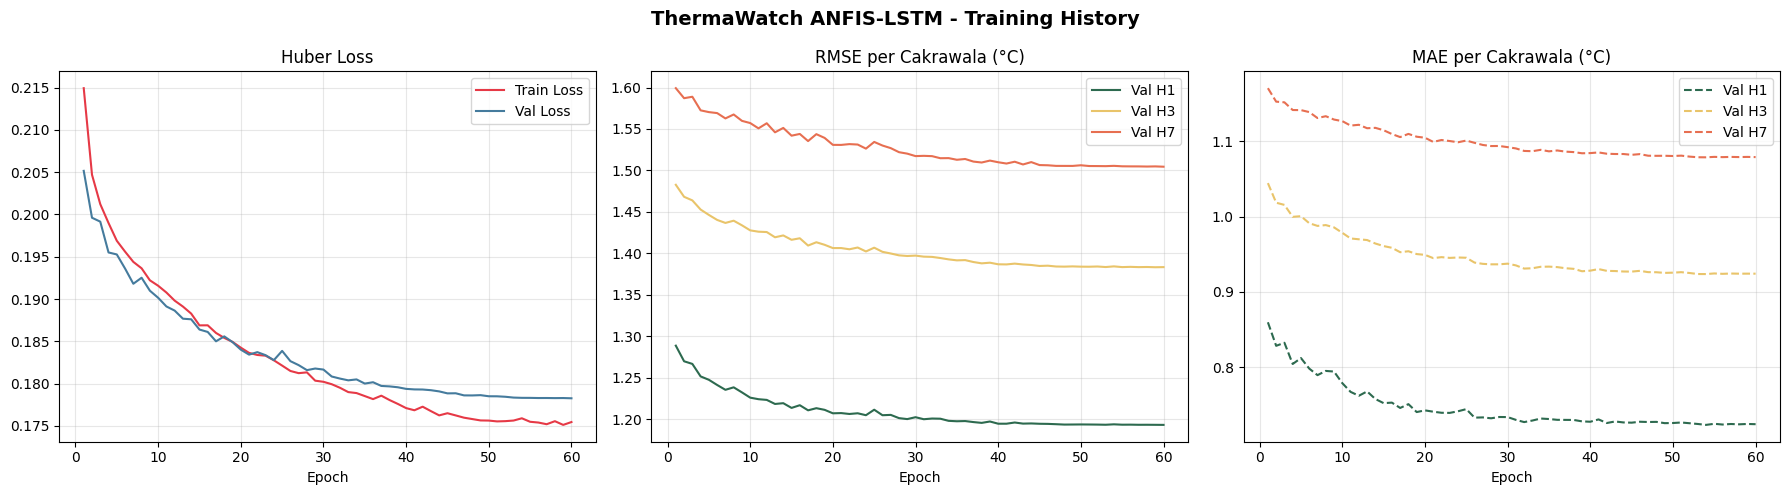

In [26]:
# BAGIAN 4 - VISUALISASI TRAINING HISTORY

def plot_training_history(history, save_path=CFG.OUTPUT_DIR + 'training_history.png'):
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle('ThermaWatch ANFIS-LSTM - Training History', fontsize=14, fontweight='bold')
    epochs_ax = range(1, len(history['train_loss']) + 1)

    # Panel 1: Loss
    axes[0].plot(epochs_ax, history['train_loss'], label='Train Loss', color='#E63946')
    axes[0].plot(epochs_ax, history['val_loss'],   label='Val Loss',   color='#457B9D')
    axes[0].set_title('Huber Loss'); axes[0].set_xlabel('Epoch'); axes[0].legend()
    axes[0].grid(alpha=0.3)

    # Panel 2: RMSE
    colors = {'H1': '#2D6A4F', 'H3': '#E9C46A', 'H7': '#E76F51'}
    for h, c in colors.items():
        axes[1].plot(epochs_ax, history[f'val_{h}_RMSE'], label=f'Val {h}', color=c)
    axes[1].set_title('RMSE per Cakrawala (°C)'); axes[1].set_xlabel('Epoch'); axes[1].legend()
    axes[1].grid(alpha=0.3)

    # Panel 3: MAE
    for h, c in colors.items():
        axes[2].plot(epochs_ax, history[f'val_{h}_MAE'], label=f'Val {h}', color=c, linestyle='--')
    axes[2].set_title('MAE per Cakrawala (°C)'); axes[2].set_xlabel('Epoch'); axes[2].legend()
    axes[2].grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    print(f'  [VIZ] Training history disimpan -> {save_path}')
    plt.show()


plot_training_history(history)

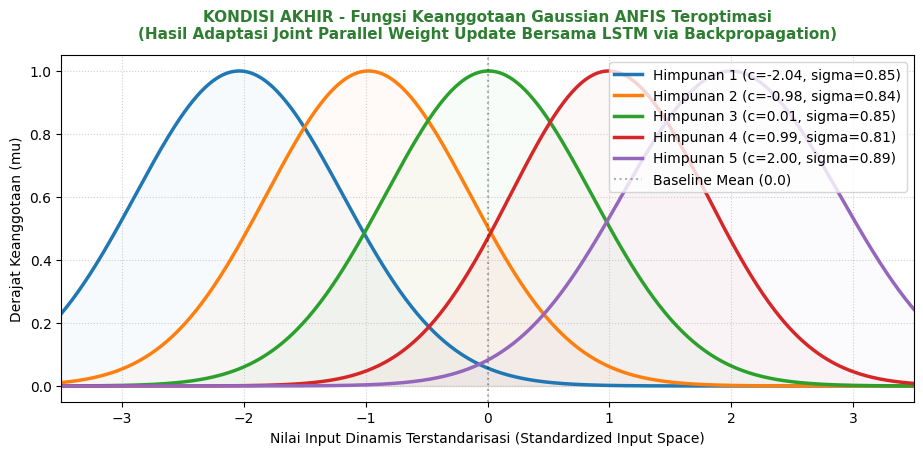

Grafik fungsi keanggotaan teroptimasi berhasil disimpan ke: /content/drive/MyDrive/Kuliah/outputs/anfis_membership_final_LST_Anomaly.png


In [27]:
# VISUALISASI ANFIS PART 2 - HASIL AKHIR GAUSSIAN MEMBERSHIP FUNCTION (TEROPTIMASI)
import numpy as np
import torch
import matplotlib.pyplot as plt

def plot_trained_membership(trained_model, feature_idx=2, feature_name="LST_Anomaly"):
    """
    Fungsi untuk mengekstrak parameter aktual hasil backpropagation dari layer ANFIS
    dan memvisualisasikan bentuk akhir kurva yang adaptif.
    """
    trained_model.eval()
    with torch.no_grad():
        # Mengekstrak nilai parameter c dan sigma langsung dari arsitektur PyTorch yang telah ditraining
        centers_after = trained_model.fuzzy_layer.centers[feature_idx].cpu().numpy()
        sigmas_after = torch.exp(trained_model.fuzzy_layer.log_sigma[feature_idx]).cpu().numpy()

    # Rentang sumbu X (disamakan dengan skala grafik awal untuk perbandingan yang adil)
    x = np.linspace(-3.5, 3.5, 600)
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']

    plt.figure(figsize=(11, 4.5))

    # Menggambar kurva Gaussian hasil adaptasi gradien bersama LSTM
    for i in range(CFG.FUZZY_SETS):
        y_after = np.exp(-0.5 * ((x - centers_after[i]) / sigmas_after[i]) ** 2)

        plt.plot(x, y_after, color=colors[i], linewidth=2.5,
                 label=f'Himpunan {i+1} (c={centers_after[i]:.2f}, sigma={sigmas_after[i]:.2f})')
        plt.fill_between(x, 0, y_after, color=colors[i], alpha=0.03)

    plt.title('KONDISI AKHIR - Fungsi Keanggotaan Gaussian ANFIS Teroptimasi\n(Hasil Adaptasi Joint Parallel Weight Update Bersama LSTM via Backpropagation)',
              fontsize=11, fontweight='bold', color='#2e7d32', pad=12)
    plt.ylabel('Derajat Keanggotaan (mu)', fontsize=10)
    plt.xlabel('Nilai Input Dinamis Terstandarisasi (Standardized Input Space)', fontsize=10)
    plt.axvline(x=0, color='black', linestyle=':', alpha=0.3, label='Baseline Mean (0.0)')
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.legend(loc='upper right', frameon=True, shadow=False)
    plt.ylim(-0.05, 1.05)
    plt.xlim(-3.5, 3.5)

    # Auto-save kurva final beresolusi tinggi ke Google Drive kamu
    final_output_path = CFG.OUTPUT_DIR + f'anfis_membership_final_{feature_name}.png'
    plt.savefig(final_output_path, bbox_inches='tight', dpi=300)
    plt.show()
    print(f"Grafik fungsi keanggotaan teroptimasi berhasil disimpan ke: {final_output_path}")

# Jalankan fungsi visualisasi akhir (Index 2 ditujukan untuk memantau fitur LST_Anomaly)
plot_trained_membership(model, feature_idx=2, feature_name="LST_Anomaly")

## Cell 10 - Visualisasi Aktual vs Prediksi

  [VIZ] Plot disimpan -> /content/drive/MyDrive/Kuliah/outputs/actual_vs_predicted.png


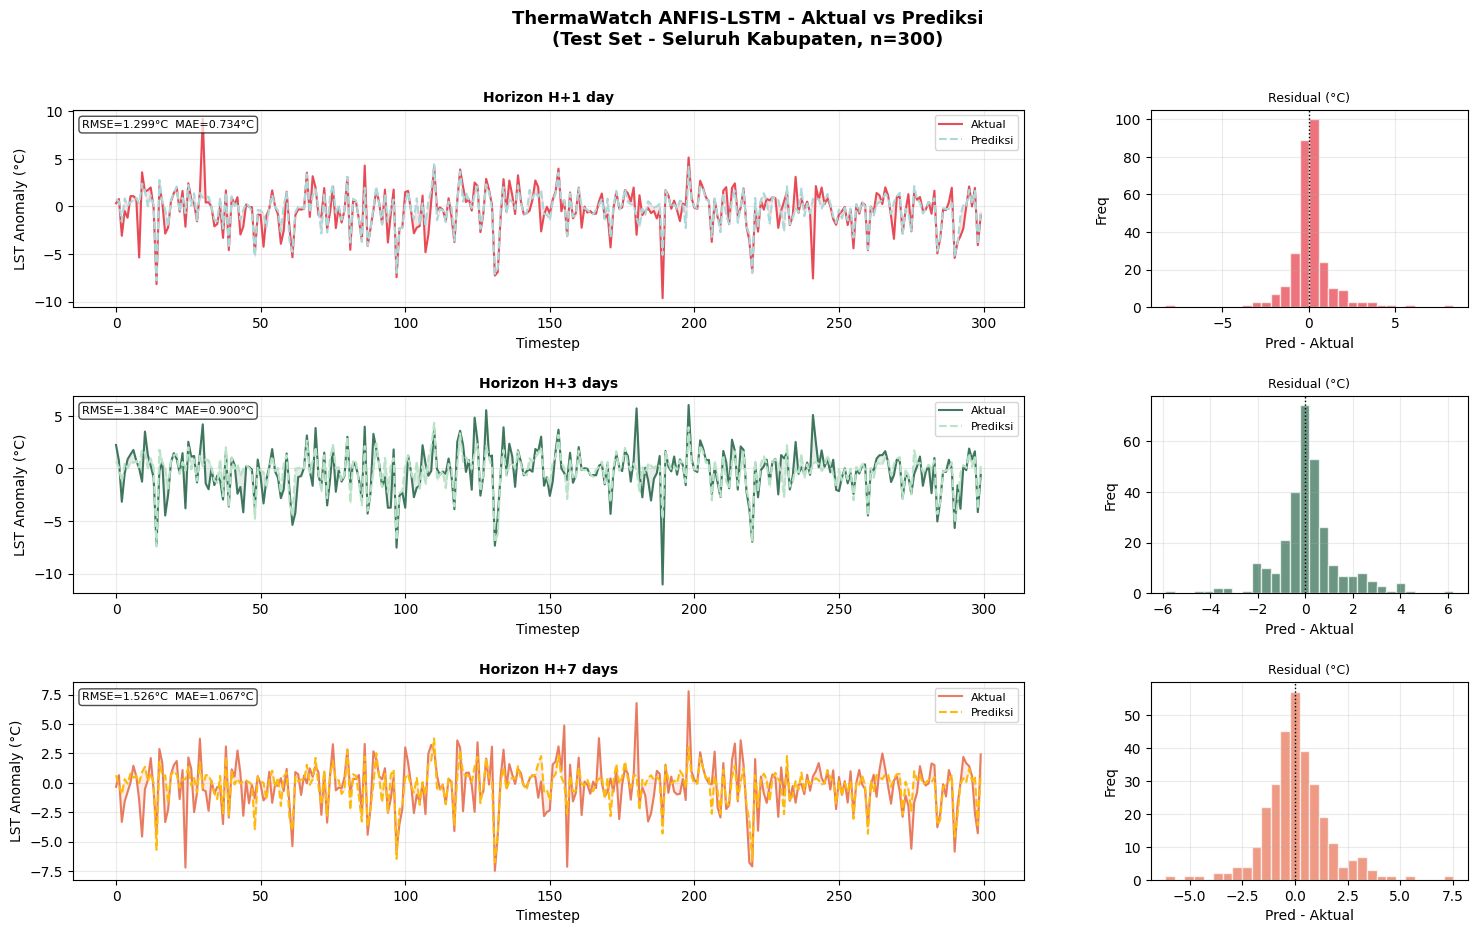

In [28]:
# BAGIAN 4 - VISUALISASI AKTUAL vs PREDIKSI

def plot_actual_vs_predicted(pred_orig, target_orig,
                              n_samples=300,
                              kabupaten_label='Test Set - Seluruh Kabupaten',
                              save_path=CFG.OUTPUT_DIR + 'actual_vs_predicted.png'):
    """
    Overlay Aktual vs Prediksi + distribusi residual untuk H1, H3, H7.

    pred_orig   : [N, 3] - prediksi dalam satuan °C asli
    target_orig : [N, 3] - aktual dalam satuan °C asli
    """
    horizons    = ['H+1 day', 'H+3 days', 'H+7 days']
    colors_act  = ['#E63946', '#2D6A4F', '#E76F51']
    colors_pred = ['#A8DADC', '#B7E4C7', '#FFBA08']

    p = pred_orig[:n_samples]
    t = target_orig[:n_samples]

    fig = plt.figure(figsize=(18, 10))
    gs  = gridspec.GridSpec(3, 2, figure=fig, width_ratios=[3, 1], hspace=0.45)
    fig.suptitle(
        f'ThermaWatch ANFIS-LSTM - Aktual vs Prediksi\n({kabupaten_label}, n={n_samples})',
        fontsize=13, fontweight='bold')

    for i in range(3):
        ax_main = fig.add_subplot(gs[i, 0])
        ax_hist = fig.add_subplot(gs[i, 1])
        x_ax    = np.arange(n_samples)

        ax_main.fill_between(x_ax, t[:, i], p[:, i], alpha=0.12, color=colors_act[i])
        ax_main.plot(x_ax, t[:, i], color=colors_act[i],  lw=1.5, label='Aktual',   alpha=0.9)
        ax_main.plot(x_ax, p[:, i], color=colors_pred[i], lw=1.5, label='Prediksi', linestyle='--')
        ax_main.set_title(f'Horizon {horizons[i]}', fontsize=10, fontweight='bold')
        ax_main.set_xlabel('Timestep'); ax_main.set_ylabel('LST Anomaly (°C)')
        ax_main.legend(fontsize=8); ax_main.grid(alpha=0.25)

        diff = p[:, i] - t[:, i]
        rmse = np.sqrt(np.mean(diff ** 2))
        mae  = np.mean(np.abs(diff))
        ax_main.annotate(f'RMSE={rmse:.3f}°C  MAE={mae:.3f}°C',
                         xy=(0.01, 0.95), xycoords='axes fraction', fontsize=8, va='top',
                         bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.7))

        ax_hist.hist(diff, bins=30, color=colors_act[i], alpha=0.7, edgecolor='white')
        ax_hist.axvline(0, color='black', lw=1, linestyle=':')
        ax_hist.set_title('Residual (°C)', fontsize=9)
        ax_hist.set_xlabel('Pred - Aktual'); ax_hist.set_ylabel('Freq')
        ax_hist.grid(alpha=0.25)

    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    print(f'  [VIZ] Plot disimpan -> {save_path}')
    plt.show()


plot_actual_vs_predicted(pred_orig, target_orig)

## Cell 11 - Simpan Scaler ke Drive (untuk Inference)

In [29]:
# RINGKASAN OUTPUT & SCALER RESMI

import os

scaler_path = CFG.OUTPUT_DIR + 'scalers.pkl'

# Cek apakah file scaler yang dibuat otomatis oleh build_dataloaders() sudah ada
if os.path.exists(scaler_path):
    print(f'Scaler Resmi Terverifikasi Aman -> {scaler_path}')
    print('File ini WAJIB disertakan saat melakukan inference/prediksi di Streamlit nanti.')
else:
    print(f'Peringatan: File {scaler_path} belum ditemukan!')
    print('Pastikan kamu sudah menjalankan cell build_dataloaders() yang baru.')

# Ringkasan semua output yang tersimpan di Google Drive
print('\nOutput files di Google Drive:')
for fname in ['best_model.pt', 'scalers.pkl', 'training_history.png', 'actual_vs_predicted.png']:
    fpath = CFG.OUTPUT_DIR + fname
    if os.path.exists(fpath):
        size_kb = os.path.getsize(fpath) / 1000
        print(f'   {fname:<35} ({size_kb:.1f} KB)')
    else:
        print(f'   {fname} - belum tersedia / belum dijalankan')

Scaler Resmi Terverifikasi Aman -> /content/drive/MyDrive/Kuliah/outputs/scalers.pkl
File ini WAJIB disertakan saat melakukan inference/prediksi di Streamlit nanti.

Output files di Google Drive:
   best_model.pt                       (11147.3 KB)
   scalers.pkl                         (1.0 KB)
   training_history.png                (156.0 KB)
   actual_vs_predicted.png             (530.6 KB)


## Cell 12 - Inference / Prediksi Data Baru

In [30]:
# 1. LOAD SCALER RESMI DARI PICKLE
scaler_path = CFG.OUTPUT_DIR + 'scalers.pkl'
print(f"Memuat file scaler resmi dari: {scaler_path} ...")

with open(scaler_path, 'rb') as f:
    loaded_scalers = pickle.load(f)

# Ekstrak masing-masing scaler ke dalam variabel global
scaler_dyn_official   = loaded_scalers['scaler_dyn']
scaler_stat_official  = loaded_scalers['scaler_stat']
scaler_y_official     = loaded_scalers['scaler_y']
print("Scaler resmi berhasil dimuat ke dalam fungsi inference!")


# 2. FUNGSI INFERENCE DENGAN OUTPUT SUHU RIIL & ESTIMASI SUHU PREDIKSI
def predict_single_window_fixed(model, df_window, device=CFG.DEVICE):
    assert len(df_window) == CFG.LOOKBACK, f'Butuh tepat {CFG.LOOKBACK} baris!'

    # 1. Ambil nilai historis hari terakhir di window untuk referensi tampilan
    suhu_riil_terakhir = df_window['MODIS_LST_Mean'].iloc[-1]
    anomali_terakhir = df_window['LST_Anomaly'].iloc[-1]
    hist_mean_base = df_window['LST_Historical_Mean'].iloc[-1]

    # 2. Transformasi fitur menggunakan scaler resmi hasil load pickle
    x_dyn_raw  = scaler_dyn_official.transform(df_window[CFG.DYNAMIC_COLS].values).astype(np.float32)
    x_stat_raw = scaler_stat_official.transform(df_window[CFG.STATIC_COLS].values[-1:]).astype(np.float32)

    x_dyn  = torch.tensor(x_dyn_raw).unsqueeze(0).to(device)
    x_stat = torch.tensor(x_stat_raw).to(device)

    model.eval()
    with torch.no_grad():
        pred_scaled = model(x_dyn, x_stat).cpu().numpy()

    # 3. Denormalisasi target anomali (°C)
    pred_orig = scaler_y_official.inverse_transform(pred_scaled)[0]

    # 4. Logika status threshold early warning
    def dapatkan_status(nilai_anomali):
        if nilai_anomali >= 2.5:
            return "BAHAYA (Anomali Termal Tinggi - Potensi Manifestasi Aktif)"
        elif nilai_anomali >= 1.0:
            return "WASPADA (Anomali Termal Sedang - Pantau Berkala)"
        elif nilai_anomali <= -2.0:
            return "ANOMALIS DINGIN (Penurunan Suhu Ekstrem)"
        else:
            return "AMAN (Fluktuasi Suhu Normal)"

    # 5. Hitung Estimasi Suhu Prediksi Aktual (Suhu Aktual = Anomali + Historical Mean)
    suhu_pred_h1 = pred_orig[0] + hist_mean_base
    suhu_pred_h3 = pred_orig[1] + hist_mean_base
    suhu_pred_h7 = pred_orig[2] + hist_mean_base

    return {
        'meta': {
            'suhu_riil_terakhir': round(float(suhu_riil_terakhir), 4),
            'anomali_terakhir': round(float(anomali_terakhir), 4)
        },
        'H1': {
            'anomali': round(float(pred_orig[0]), 4),
            'suhu_estimasi': round(float(suhu_pred_h1), 4),
            'status': dapatkan_status(pred_orig[0])
        },
        'H3': {
            'anomali': round(float(pred_orig[1]), 4),
            'suhu_estimasi': round(float(suhu_pred_h3), 4),
            'status': dapatkan_status(pred_orig[1])
        },
        'H7': {
            'anomali': round(float(pred_orig[2]), 4),
            'suhu_estimasi': round(float(suhu_pred_h7), 4),
            'status': dapatkan_status(pred_orig[2])
        }
    }


# 3. JALANKAN PREDIKSI & TAMPILKAN MATRIKS LENGKAP (VERSI DATA TENGAH)
df_full = pd.read_csv(CFG.DATA_PATH)
df_full = df_full.sort_values(['Kabupaten', 'date']).reset_index(drop=True)

# Pilih kabupaten sampel
sample_kab = df_full['Kabupaten'].unique()[0]
df_kab_only = df_full[df_full['Kabupaten'] == sample_kab]

# Ambil baris dari tengah-tengah dataset
index_tengah = len(df_kab_only) // 2
df_sample_tengah = df_kab_only.iloc[index_tengah : index_tengah + CFG.LOOKBACK]

# Ambil nilai rata-rata historis bulanan dari data asli untuk visualisasi
rata_historis_tengah = df_sample_tengah['LST_Historical_Mean'].iloc[-1]

# Jalankan fungsi prediksi
result_tengah = predict_single_window_fixed(model, df_sample_tengah)

# TAMPILKAN OUTPUT DETAIL LENGKAP VERSI DATA TENGAH
print(f'\n==================================================================')
print(f'   SYSTEM EARLY WARNING THERMAWATCH - KABUPATEN: {sample_kab.upper()} (VERSI DATA TENGAH)')
print(f'====================================================================')
print(f' Rentang Window Input       : {df_sample_tengah["date"].iloc[0]} s/d {df_sample_tengah["date"].iloc[-1]}')
print(f' Rata-rata Suhu Historis    : {rata_historis_tengah:.2f} °C (Base Baseline Bulanan)')
print(f' Suhu Riil Terakhir (di CSV)  : {result_tengah["meta"]["suhu_riil_terakhir"]:.2f} °C (Anomali: {result_tengah["meta"]["anomali_terakhir"]:+.4f} °C)')
print(f'--------------------------------------------------------------------')
print(f' PREDIKSI H+1:')
print(f'    Selisih Anomali   : {result_tengah["H1"]["anomali"]:+.4f} °C')
print(f'    Estimasi Suhu LST : {result_tengah["H1"]["suhu_estimasi"]:.2f} °C')
print(f'    Status Peringatan : {result_tengah["H1"]["status"]}')
print(f'\n PREDIKSI H+3:')
print(f'    Selisih Anomali   : {result_tengah["H3"]["anomali"]:+.4f} °C')
print(f'    Estimasi Suhu LST : {result_tengah["H3"]["suhu_estimasi"]:.2f} °C')
print(f'    Status Peringatan : {result_tengah["H3"]["status"]}')
print(f'\n PREDIKSI H+7:')
print(f'    Selisih Anomali   : {result_tengah["H7"]["anomali"]:+.4f} °C')
print(f'    Estimasi Suhu LST : {result_tengah["H7"]["suhu_estimasi"]:.2f} °C')
print(f'    Status Peringatan : {result_tengah["H7"]["status"]}')
print(f'====================================================================')

Memuat file scaler resmi dari: /content/drive/MyDrive/Kuliah/outputs/scalers.pkl ...
Scaler resmi berhasil dimuat ke dalam fungsi inference!

   SYSTEM EARLY WARNING THERMAWATCH - KABUPATEN: BANDUNG (VERSI DATA TENGAH)
 Rentang Window Input       : 2020-03-13 s/d 2020-03-26
 Rata-rata Suhu Historis    : 30.14 °C (Base Baseline Bulanan)
 Suhu Riil Terakhir (di CSV)  : 28.43 °C (Anomali: -1.7123 °C)
--------------------------------------------------------------------
 PREDIKSI H+1:
    Selisih Anomali   : -0.3605 °C
    Estimasi Suhu LST : 29.78 °C
    Status Peringatan : AMAN (Fluktuasi Suhu Normal)

 PREDIKSI H+3:
    Selisih Anomali   : -0.0517 °C
    Estimasi Suhu LST : 30.09 °C
    Status Peringatan : AMAN (Fluktuasi Suhu Normal)

 PREDIKSI H+7:
    Selisih Anomali   : +0.2239 °C
    Estimasi Suhu LST : 30.36 °C
    Status Peringatan : AMAN (Fluktuasi Suhu Normal)


In [31]:
# 4. JALANKAN PREDIKSI & TAMPILKAN MATRIKS LENGKAP (VERSI DATA TAIL + HISTORIS)
# (Gunakan df_kab_only yang sudah terfilter dari cell atasnya)

# Ambil data paling belakang/ekor
df_sample_tail = df_kab_only.tail(CFG.LOOKBACK)

# Ambil nilai rata-rata historis bulanan dari data ekor untuk visualisasi
rata_historis_tail = df_sample_tail['LST_Historical_Mean'].iloc[-1]

# Jalankan fungsi prediksi menggunakan data tail
result_tail = predict_single_window_fixed(model, df_sample_tail)

# TAMPILKAN OUTPUT DETAIL LENGKAP VERSI DATA TAIL
print(f'\n==================================================================')
print(f'   SYSTEM EARLY WARNING THERMAWATCH - KABUPATEN: {sample_kab.upper()} (VERSI DATA TAIL)')
print(f'====================================================================')
print(f' Rentang Window Input       : {df_sample_tail["date"].iloc[0]} s/d {df_sample_tail["date"].iloc[-1]} (Ujung Akhir Dataset)')
print(f' Rata-rata Suhu Historis    : {rata_historis_tail:.2f} °C (Base Baseline Bulanan)')
print(f' Suhu Riil Terakhir (di CSV)  : {result_tail["meta"]["suhu_riil_terakhir"]:.2f} °C (Anomali: {result_tail["meta"]["anomali_terakhir"]:+.4f} °C)')
print(f'--------------------------------------------------------------------')
print(f' PREDIKSI H+1:')
print(f'    Selisih Anomali   : {result_tail["H1"]["anomali"]:+.4f} °C')
print(f'    Estimasi Suhu LST : {result_tail["H1"]["suhu_estimasi"]:.2f} °C')
print(f'    Status Peringatan : {result_tail["H1"]["status"]}')
print(f'\n PREDIKSI H+3:')
print(f'    Selisih Anomali   : {result_tail["H3"]["anomali"]:+.4f} °C')
print(f'    Estimasi Suhu LST : {result_tail["H3"]["suhu_estimasi"]:.2f} °C')
print(f'    Status Peringatan : {result_tail["H3"]["status"]}')
print(f'\n PREDIKSI H+7:')
print(f'    Selisih Anomali   : {result_tail["H7"]["anomali"]:+.4f} °C')
print(f'    Estimasi Suhu LST : {result_tail["H7"]["suhu_estimasi"]:.2f} °C')
print(f'    Status Peringatan : {result_tail["H7"]["status"]}')
print(f'====================================================================')


   SYSTEM EARLY WARNING THERMAWATCH - KABUPATEN: BANDUNG (VERSI DATA TAIL)
 Rentang Window Input       : 2026-05-10 s/d 2026-05-23 (Ujung Akhir Dataset)
 Rata-rata Suhu Historis    : 29.26 °C (Base Baseline Bulanan)
 Suhu Riil Terakhir (di CSV)  : 26.20 °C (Anomali: -3.0579 °C)
--------------------------------------------------------------------
 PREDIKSI H+1:
    Selisih Anomali   : -2.8076 °C
    Estimasi Suhu LST : 26.45 °C
    Status Peringatan : ANOMALIS DINGIN (Penurunan Suhu Ekstrem)

 PREDIKSI H+3:
    Selisih Anomali   : -2.8857 °C
    Estimasi Suhu LST : 26.37 °C
    Status Peringatan : ANOMALIS DINGIN (Penurunan Suhu Ekstrem)

 PREDIKSI H+7:
    Selisih Anomali   : -2.7969 °C
    Estimasi Suhu LST : 26.46 °C
    Status Peringatan : ANOMALIS DINGIN (Penurunan Suhu Ekstrem)


In [35]:
# 5. SIMULASI PREDIKSI DENGAN ANOMALI SUHU TINGGI

# Pastikan df_kab_only tersedia untuk simulasi
df_full = pd.read_csv(CFG.DATA_PATH)
df_full = df_full.sort_values(['Kabupaten', 'date']).reset_index(drop=True)
sample_kab = df_full['Kabupaten'].unique()[0]
df_kab_only = df_full[df_full['Kabupaten'] == sample_kab]

# Ambil salinan dari df_kab_only.tail() agar tidak mengubah data asli
df_simulasi_tinggi = df_kab_only.tail(CFG.LOOKBACK).copy()

# INPUT SUHU DARI PENGGUNA UNTUK SIMULASI
# @param {type:"raw"} [Masukkan list berisi 14 suhu (float) untuk simulasi, cth: [25.0, 25.1, 25.2, 25.3, 25.4, 25.5, 25.6, 25.7, 25.8, 25.9, 26.0, 26.5, 27.0, 32.0]]
SUHU_SIMULASI_USER_LIST = [25.0, 25.1, 25.2, 25.3, 25.4, 25.5, 25.6, 25.7, 25.8, 25.9, 26.0, 26.5, 27.0, 32.0]

print(f"\nMelakukan simulasi dengan list suhu input Anda:")
for i, temp in enumerate(SUHU_SIMULASI_USER_LIST):
    print(f"   Hari {i+1}: {temp}°C")

# Validasi jumlah input suhu
if len(SUHU_SIMULASI_USER_LIST) != CFG.LOOKBACK:
    raise ValueError(f"Mohon masukkan tepat {CFG.LOOKBACK} nilai suhu untuk simulasi (saat ini {len(SUHU_SIMULASI_USER_LIST)}).")

# MODIFIKASI DATA UNTUK SIMULASI ANOMALI BERDASARKAN SUHU USER
# Ambil nilai rata-rata historis bulanan untuk setiap hari dalam window
hist_mean_series = df_simulasi_tinggi['LST_Historical_Mean'].values

# Update ERA5_LST_Mean dan LST_Anomaly berdasarkan input user
df_simulasi_tinggi['ERA5_LST_Mean'] = SUHU_SIMULASI_USER_LIST
df_simulasi_tinggi['LST_Anomaly'] = np.array(SUHU_SIMULASI_USER_LIST) - hist_mean_series

# Jalankan fungsi prediksi menggunakan data simulasi
result_simulasi = predict_single_window_fixed(model, df_simulasi_tinggi)

# TAMPILKAN OUTPUT DETAIL LENGKAP VERSI DATA SIMULASI
print(f'\n==================================================================')
print(f'   SYSTEM EARLY WARNING THERMAWATCH - KABUPATEN: {sample_kab.upper()} (VERSI DATA SIMULASI)')
print(f'====================================================================')
print(f' Rentang Window Input       : {df_simulasi_tinggi["date"].iloc[0]} s/d {df_simulasi_tinggi["date"].iloc[-1]} (Simulasi)')
# The last historical mean is used for the anomaly calculation in predict_single_window_fixed
rata_historis_simulasi = df_simulasi_tinggi['LST_Historical_Mean'].iloc[-1]
print(f' Rata-rata Suhu Historis    : {rata_historis_simulasi:.2f} °C (Base Baseline Bulanan)')
print(f' Suhu Riil Terakhir (Simulasi): {result_simulasi["meta"]["suhu_riil_terakhir"]:.2f} °C (Anomali: {result_simulasi["meta"]["anomali_terakhir"]:+.4f} °C)')
print(f'--------------------------------------------------------------------')
print(f' PREDIKSI H+1:')
print(f'    Selisih Anomali   : {result_simulasi["H1"]["anomali"]:+.4f} °C')
print(f'    Estimasi Suhu LST : {result_simulasi["H1"]["suhu_estimasi"]:.2f} °C')
print(f'    Status Peringatan : {result_simulasi["H1"]["status"]}')
print(f'\n PREDIKSI H+3:')
print(f'    Selisih Anomali   : {result_simulasi["H3"]["anomali"]:+.4f} °C')
print(f'    Estimasi Suhu LST : {result_simulasi["H3"]["suhu_estimasi"]:.2f} °C')
print(f'    Status Peringatan : {result_simulasi["H3"]["status"]}')
print(f'\n PREDIKSI H+7:')
print(f'    Selisih Anomali   : {result_simulasi["H7"]["anomali"]:+.4f} °C')
print(f'    Estimasi Suhu LST : {result_simulasi["H7"]["suhu_estimasi"]:.2f} °C')
print(f'    Status Peringatan : {result_simulasi["H7"]["status"]}')
print(f'====================================================================')


Melakukan simulasi dengan list suhu input Anda:
   Hari 1: 25.0°C
   Hari 2: 25.1°C
   Hari 3: 25.2°C
   Hari 4: 25.3°C
   Hari 5: 25.4°C
   Hari 6: 25.5°C
   Hari 7: 25.6°C
   Hari 8: 25.7°C
   Hari 9: 25.8°C
   Hari 10: 25.9°C
   Hari 11: 26.0°C
   Hari 12: 26.5°C
   Hari 13: 27.0°C
   Hari 14: 32.0°C

   SYSTEM EARLY WARNING THERMAWATCH - KABUPATEN: BANDUNG (VERSI DATA SIMULASI)
 Rentang Window Input       : 2026-05-10 s/d 2026-05-23 (Simulasi)
 Rata-rata Suhu Historis    : 29.26 °C (Base Baseline Bulanan)
 Suhu Riil Terakhir (Simulasi): 26.20 °C (Anomali: +2.7440 °C)
--------------------------------------------------------------------
 PREDIKSI H+1:
    Selisih Anomali   : -1.9805 °C
    Estimasi Suhu LST : 27.28 °C
    Status Peringatan : AMAN (Fluktuasi Suhu Normal)

 PREDIKSI H+3:
    Selisih Anomali   : -2.1570 °C
    Estimasi Suhu LST : 27.10 °C
    Status Peringatan : ANOMALIS DINGIN (Penurunan Suhu Ekstrem)

 PREDIKSI H+7:
    Selisih Anomali   : -2.1383 °C
    Estimasi Suh